# Tuần 5: X-Learner (Causal Inference - Uplift Modeling)
Giải quyết bài toán cá nhân hóa khuyến mãi bằng thuật toán X-Learner (Tự code tay bằng XGBoost).


In [21]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)


## 1. Chuẩn bị Dữ liệu (Kế thừa từ T-Learner)


In [22]:
# Load data
df = pd.read_csv('../../../data/processed/segmented_simulation_data.csv')
df['is_credit_card'] = (df['payment_type'] == 1).astype(int)

print(f"Tổng số lượng khách hàng toàn hệ thống: {len(df)}")

# Khai báo biến (Sử dụng Toàn bộ dữ liệu)
features = ['age', 'is_urban', 'preferred_hour', 'is_rush_hour', 'is_airport_trip', 'is_rain_rider', 'is_weekend_rider', 'is_credit_card', 'passenger_count', 'monthly_rides_history', 'recency_days']
X = df[features]
y = df['Y_rand']
T = df['treatment_rand']

# Train (60%), Val (20%), Test (20%)
X_train_val, X_test, y_train_val, y_test, T_train_val, T_test = train_test_split(X, y, T, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val, T_train, T_val = train_test_split(X_train_val, y_train_val, T_train_val, test_size=0.25, random_state=42)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")


Tổng số lượng khách hàng toàn hệ thống: 20000
Train size: 12000 | Val size: 4000 | Test size: 4000


## 2. Thuật toán X-Learner (4 Bước)
### Bước 1: Base Models (Dự đoán Y cho nhóm Control và Treatment)


In [23]:
# Chia dữ liệu theo Treatment (T=1) và Control (T=0)
X_train_0, y_train_0 = X_train[T_train == 0], y_train[T_train == 0]
X_train_1, y_train_1 = X_train[T_train == 1], y_train[T_train == 1]
X_val_0, y_val_0 = X_val[T_val == 0], y_val[T_val == 0]
X_val_1, y_val_1 = X_val[T_val == 1], y_val[T_val == 1]

# Base Model cho nhóm Control (mu_0)
model_0 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42, min_child_weight=5, reg_lambda=1.0, early_stopping_rounds=10)
model_0.fit(X_train_0, y_train_0, eval_set=[(X_val_0, y_val_0)], verbose=False)

# Base Model cho nhóm Treatment (mu_1)
model_1 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42, min_child_weight=5, reg_lambda=1.0, early_stopping_rounds=10)
model_1.fit(X_train_1, y_train_1, eval_set=[(X_val_1, y_val_1)], verbose=False)

print("--- ĐÁNH GIÁ MÔ HÌNH CƠ SỞ ---")
print(f"Model 0 (mu_0) - RMSE: {np.sqrt(mean_squared_error(y_val_0, model_0.predict(X_val_0))):.3f}")
print(f"Model 1 (mu_1) - RMSE: {np.sqrt(mean_squared_error(y_val_1, model_1.predict(X_val_1))):.3f}")


--- ĐÁNH GIÁ MÔ HÌNH CƠ SỞ ---
Model 0 (mu_0) - RMSE: 6.328
Model 1 (mu_1) - RMSE: 6.379


### Bước 2: Impute Counterfactuals (Nội suy Hiệu ứng)


In [24]:
# Nội suy hiệu ứng (Pseudo-effect) cho tập Train
pseudo_effect_1 = y_train_1 - model_0.predict(X_train_1)
pseudo_effect_0 = model_1.predict(X_train_0) - y_train_0

# Nội suy hiệu ứng cho tập Val (để Early Stopping ở bước 3)
pseudo_effect_val_1 = y_val_1 - model_0.predict(X_val_1)
pseudo_effect_val_0 = model_1.predict(X_val_0) - y_val_0

print("Đã nội suy xong Hiệu ứng Counterfactual cho cả 2 nhóm.")


Đã nội suy xong Hiệu ứng Counterfactual cho cả 2 nhóm.


### Bước 3: Second-stage Models (Học trực tiếp trên Hiệu ứng)


In [25]:
# Mô hình tau_1 học trên nhóm T=1
model_tau_1 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42, min_child_weight=5, reg_lambda=1.0, early_stopping_rounds=10)
model_tau_1.fit(X_train_1, pseudo_effect_1, eval_set=[(X_val_1, pseudo_effect_val_1)], verbose=False)

# Mô hình tau_0 học trên nhóm T=0
model_tau_0 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42, min_child_weight=5, reg_lambda=1.0, early_stopping_rounds=10)
model_tau_0.fit(X_train_0, pseudo_effect_0, eval_set=[(X_val_0, pseudo_effect_val_0)], verbose=False)

print("Đã huấn luyện xong 2 mô hình Second-stage (tau_0 và tau_1).")


Đã huấn luyện xong 2 mô hình Second-stage (tau_0 và tau_1).


### Bước 4: Propensity Weighting (Tính CATE cuối cùng)


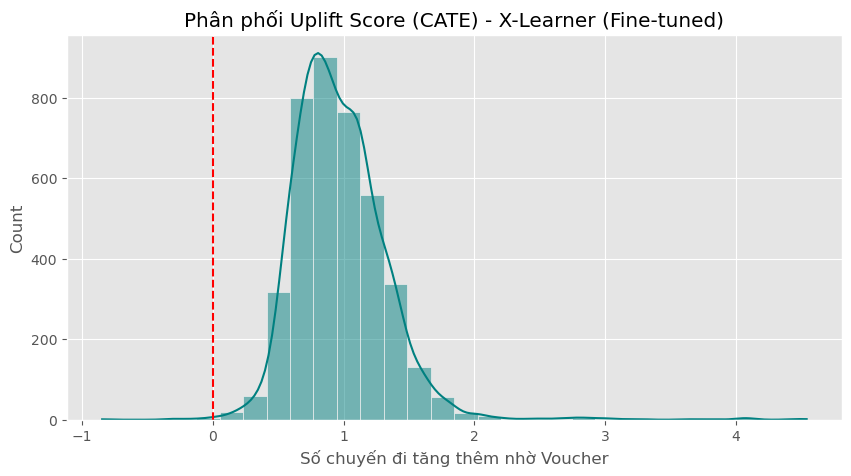

In [26]:
# Ép Propensity Score g(X) về 0.5 (Vì dữ liệu từ A/B Testing 50/50 ngẫu nhiên)
g_X = np.full(len(X_test), 0.5)

# Dự đoán CATE từ 2 mô hình tau_0 và tau_1
tau_0_pred = model_tau_0.predict(X_test)
tau_1_pred = model_tau_1.predict(X_test)

# Kết hợp (Weighted Average) tạo ra CATE cuối cùng
cate_pred_x = g_X * tau_0_pred + (1 - g_X) * tau_1_pred

df_res_x = pd.DataFrame({
    'y_true': y_test,
    'T': T_test,
    'pred_1': model_1.predict(X_test), # Vẫn cần dự đoán Y1 để tính chi phí
    'CATE_pred': cate_pred_x,
    'user_avg_fare': df.loc[X_test.index, 'avg_fare_per_trip'].values,
    'monthly_rides_history': X_test['monthly_rides_history'].values
})

plt.figure(figsize=(10, 5))
sns.histplot(df_res_x['CATE_pred'], bins=30, kde=True, color='teal')
plt.title('Phân phối Uplift Score (CATE) - X-Learner (Fine-tuned)')
plt.xlabel('Số chuyến đi tăng thêm nhờ Voucher')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()


## 3. Đánh giá Uplift bằng Qini Curve
Đánh giá xem liệu X-Learner có vượt trội hơn T-Learner hay không (Thực tế: X-Learner cho AUUC thấp hơn, cho thấy dấu hiệu Overfitting do phải train quá nhiều model trên tập dữ liệu này)..


C:\Users\minhh\AppData\Local\Temp\ipykernel_23652\601877013.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auuc_model = np.trapz(df_sorted['Qini'], dx=1)
C:\Users\minhh\AppData\Local\Temp\ipykernel_23652\601877013.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auuc_random = np.trapz(df_sorted['Random_Qini'], dx=1)


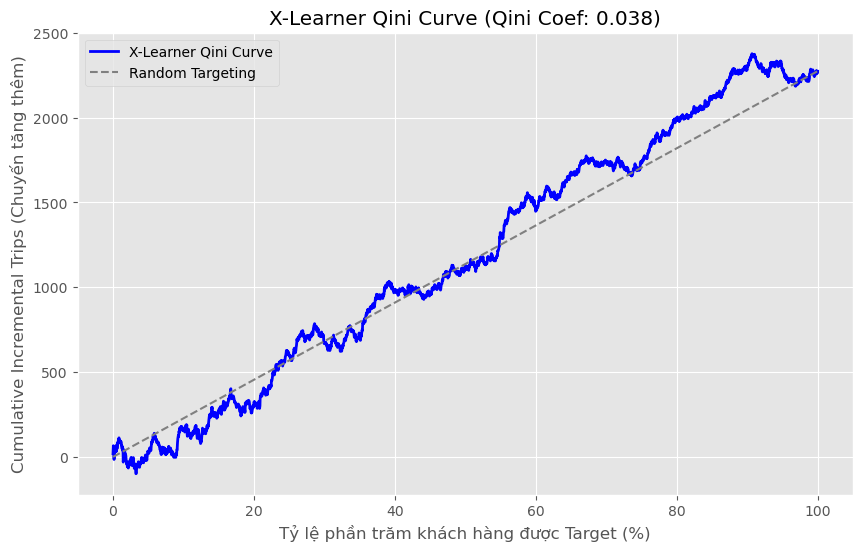

Hệ số AUUC của X-Learner: 0.038


In [27]:
def plot_qini_curve(df_res, title="Qini Curve"):
    df_sorted = df_res.sort_values(by='CATE_pred', ascending=False).reset_index(drop=True)
    
    df_sorted['T_count'] = df_sorted['T'].cumsum()
    df_sorted['C_count'] = (1 - df_sorted['T']).cumsum()
    
    df_sorted['Y_T_sum'] = (df_sorted['y_true'] * df_sorted['T']).cumsum()
    df_sorted['Y_C_sum'] = (df_sorted['y_true'] * (1 - df_sorted['T'])).cumsum()
    
    df_sorted['C_count'] = df_sorted['C_count'].replace(0, 1)
    df_sorted['Qini'] = df_sorted['Y_T_sum'] - df_sorted['Y_C_sum'] * (df_sorted['T_count'] / df_sorted['C_count'])
    
    total_uplift = df_sorted['Qini'].iloc[-1]
    df_sorted['Random_Qini'] = np.linspace(0, total_uplift, len(df_sorted))
    
    auuc_model = np.trapz(df_sorted['Qini'], dx=1)
    auuc_random = np.trapz(df_sorted['Random_Qini'], dx=1)
    
    qini_coef = (auuc_model - auuc_random) / auuc_random if auuc_random != 0 else 0
    
    plt.figure(figsize=(10, 6))
    plt.plot(df_sorted.index / len(df_sorted) * 100, df_sorted['Qini'], label='X-Learner Qini Curve', color='blue', linewidth=2)
    plt.plot(df_sorted.index / len(df_sorted) * 100, df_sorted['Random_Qini'], label='Random Targeting', color='grey', linestyle='--')
    plt.title(f'{title} (Qini Coef: {qini_coef:.3f})')
    plt.xlabel('Tỷ lệ phần trăm khách hàng được Target (%)')
    plt.ylabel('Cumulative Incremental Trips (Chuyến tăng thêm)')
    plt.legend()
    plt.show()
    
    return qini_coef

qini_score_x = plot_qini_curve(df_res_x, title="X-Learner Qini Curve")
print(f"Hệ số AUUC của X-Learner: {qini_score_x:.3f}")


## 4. Tối ưu hóa Lợi nhuận Cá nhân hóa (Profit vs CATE)


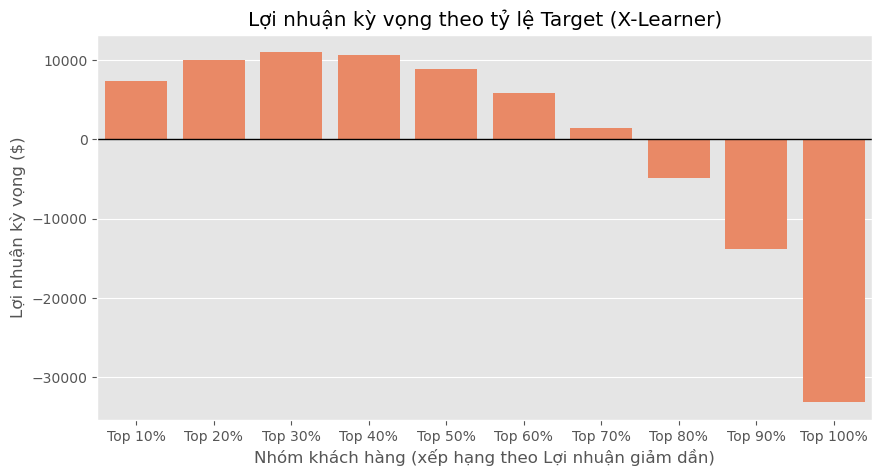

Lợi nhuận nếu phát Voucher đại trà (Top 100%): $-33,138.55
Lợi nhuận nếu chỉ phát Voucher cho Top 20% KH tốt nhất: $10,023.58
Tỷ lệ gia tăng lợi nhuận: 130.2%


In [28]:
discount_rate = 0.15
df_res_x['cost_per_ride'] = df_res_x['user_avg_fare'] * discount_rate
df_res_x['Expected_Profit'] = (df_res_x['CATE_pred'] * df_res_x['user_avg_fare']) - (df_res_x['pred_1'] * df_res_x['cost_per_ride'])

df_sorted_x = df_res_x.sort_values(by='Expected_Profit', ascending=False).reset_index(drop=True)
total_users = len(df_sorted_x)

def calc_profit_top_k(df, k_percent):
    k_users = int(total_users * (k_percent / 100))
    if k_users == 0: return 0
    target_group = df.iloc[:k_users]
    return target_group['Expected_Profit'].sum()

profits = []
k_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for k in k_values:
    profits.append(calc_profit_top_k(df_sorted_x, k))

plt.figure(figsize=(10, 5))
sns.barplot(x=[f"Top {k}%" for k in k_values], y=profits, color='coral')
plt.title('Lợi nhuận kỳ vọng theo tỷ lệ Target (X-Learner)')
plt.xlabel('Nhóm khách hàng (xếp hạng theo Lợi nhuận giảm dần)')
plt.ylabel('Lợi nhuận kỳ vọng ($)')
plt.axhline(0, color='black', linewidth=1)
plt.show()

profit_20 = calc_profit_top_k(df_sorted_x, 20)
profit_100 = calc_profit_top_k(df_sorted_x, 100)
print(f"Lợi nhuận nếu phát Voucher đại trà (Top 100%): ${profit_100:,.2f}")
print(f"Lợi nhuận nếu chỉ phát Voucher cho Top 20% KH tốt nhất: ${profit_20:,.2f}")
if profit_100 != 0:
    print(f"Tỷ lệ gia tăng lợi nhuận: {((profit_20 - profit_100) / abs(profit_100)) * 100:.1f}%")


## 5. Chân dung khách hàng (Customer Profiling)


In [29]:
df_sorted_x['is_top_20'] = np.where(df_sorted_x.index < int(total_users * 0.2), 'Top 20% (Target)', 'Bottom 80% (Ignore)')

df_profile_x = df_sorted_x.join(X_test.drop(columns=['monthly_rides_history']).reset_index(drop=True))

profile_summary_x = df_profile_x.groupby('is_top_20')[['age', 'monthly_rides_history', 'recency_days', 'user_avg_fare']].mean().round(2)
print("--- CHÂN DUNG KHÁCH HÀNG (TOP 20% vs 80%) ---")
display(profile_summary_x)


--- CHÂN DUNG KHÁCH HÀNG (TOP 20% vs 80%) ---


,age,monthly_rides_history,recency_days,user_avg_fare
is_top_20,,,,
Bottom 80% (Ignore),29.90,4.44,7.31,24.01
Top 20% (Target),30.31,0.48,7.20,35.50
